In [16]:
import os
import shutil

# Define the current working directory
current_directory = os.getcwd()

print(f"Deleting all files and directories in: {current_directory} (excluding /content/sample_data)")

# Iterate over all items in the current directory
for item in os.listdir(current_directory):
    item_path = os.path.join(current_directory, item)
    # Exclude the common Colab sample_data directory
    if item == 'sample_data':
        print(f"Skipping {item_path}")
        continue

    try:
        if os.path.isfile(item_path):
            os.remove(item_path)
            print(f"Deleted file: {item_path}")
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
            print(f"Deleted directory and its contents: {item_path}")
    except Exception as e:
        print(f"Error deleting {item_path}: {e}")

print("Deletion process complete.")

Deleting all files and directories in: /content (excluding /content/sample_data)
Skipping /content/sample_data
Deletion process complete.


✅ Dependencies installed.
📁 Upload directory: /content/structures
📁 Output directory: /content/vis_images

📤 FIRST UPLOAD (OPTIONAL): RECEPTOR PDB FILES
   These are the protein structures you used for docking.
   - If you have them, upload them now (one or many, or a ZIP).
   - If you only have docked PDBQTs and NO PDBs, click Cancel to skip.


Saving TP53_A159V.pdb to TP53_A159V.pdb
Saving TP53_A161T.pdb to TP53_A161T.pdb
Saving TP53_C17F.pdb to TP53_C17F.pdb
Saving TP53_C44F.pdb to TP53_C44F.pdb
Saving TP53_C102Y.pdb to TP53_C102Y.pdb
Saving TP53_C135F.pdb to TP53_C135F.pdb
Saving TP53_C137F.pdb to TP53_C137F.pdb
Saving TP53_C137Y.pdb to TP53_C137Y.pdb
Saving TP53_C141Y.pdb to TP53_C141Y.pdb
Saving TP53_C176F.pdb to TP53_C176F.pdb
Saving TP53_C176Y.pdb to TP53_C176Y.pdb
Saving TP53_C199Y.pdb to TP53_C199Y.pdb
Saving TP53_C238F.pdb to TP53_C238F.pdb
Saving TP53_C238Y.pdb to TP53_C238Y.pdb
Saving TP53_C242F.pdb to TP53_C242F.pdb
Saving TP53_C275Y.pdb to TP53_C275Y.pdb
Saving TP53_E126K.pdb to TP53_E126K.pdb
Saving TP53_E153K.pdb to TP53_E153K.pdb
Saving TP53_E246K.pdb to TP53_E246K.pdb
Saving TP53_E247K.pdb to TP53_E247K.pdb
Saving TP53_E285K.pdb to TP53_E285K.pdb
Saving TP53_E286K.pdb to TP53_E286K.pdb
Saving TP53_G86S.pdb to TP53_G86S.pdb
Saving TP53_G113S.pdb to TP53_G113S.pdb
Saving TP53_G206D.pdb to TP53_G206D.pdb
Saving

Saving TP53_A159V_docked.pdbqt to TP53_A159V_docked.pdbqt
Saving TP53_A161T_docked.pdbqt to TP53_A161T_docked.pdbqt
Saving TP53_C17F_docked.pdbqt to TP53_C17F_docked.pdbqt
Saving TP53_C44F_docked.pdbqt to TP53_C44F_docked.pdbqt
Saving TP53_C102Y_docked.pdbqt to TP53_C102Y_docked.pdbqt
Saving TP53_C135F_docked.pdbqt to TP53_C135F_docked.pdbqt
Saving TP53_C137F_docked.pdbqt to TP53_C137F_docked.pdbqt
Saving TP53_C137Y_docked.pdbqt to TP53_C137Y_docked.pdbqt
Saving TP53_C141Y_docked.pdbqt to TP53_C141Y_docked.pdbqt
Saving TP53_C176F_docked.pdbqt to TP53_C176F_docked.pdbqt
Saving TP53_C176Y_docked.pdbqt to TP53_C176Y_docked.pdbqt
Saving TP53_C199Y_docked.pdbqt to TP53_C199Y_docked.pdbqt
Saving TP53_C238F_docked.pdbqt to TP53_C238F_docked.pdbqt
Saving TP53_C238Y_docked.pdbqt to TP53_C238Y_docked.pdbqt
Saving TP53_C242F_docked.pdbqt to TP53_C242F_docked.pdbqt
Saving TP53_C275Y_docked.pdbqt to TP53_C275Y_docked.pdbqt
Saving TP53_E126K_docked.pdbqt to TP53_E126K_docked.pdbqt
Saving TP53_E153K_

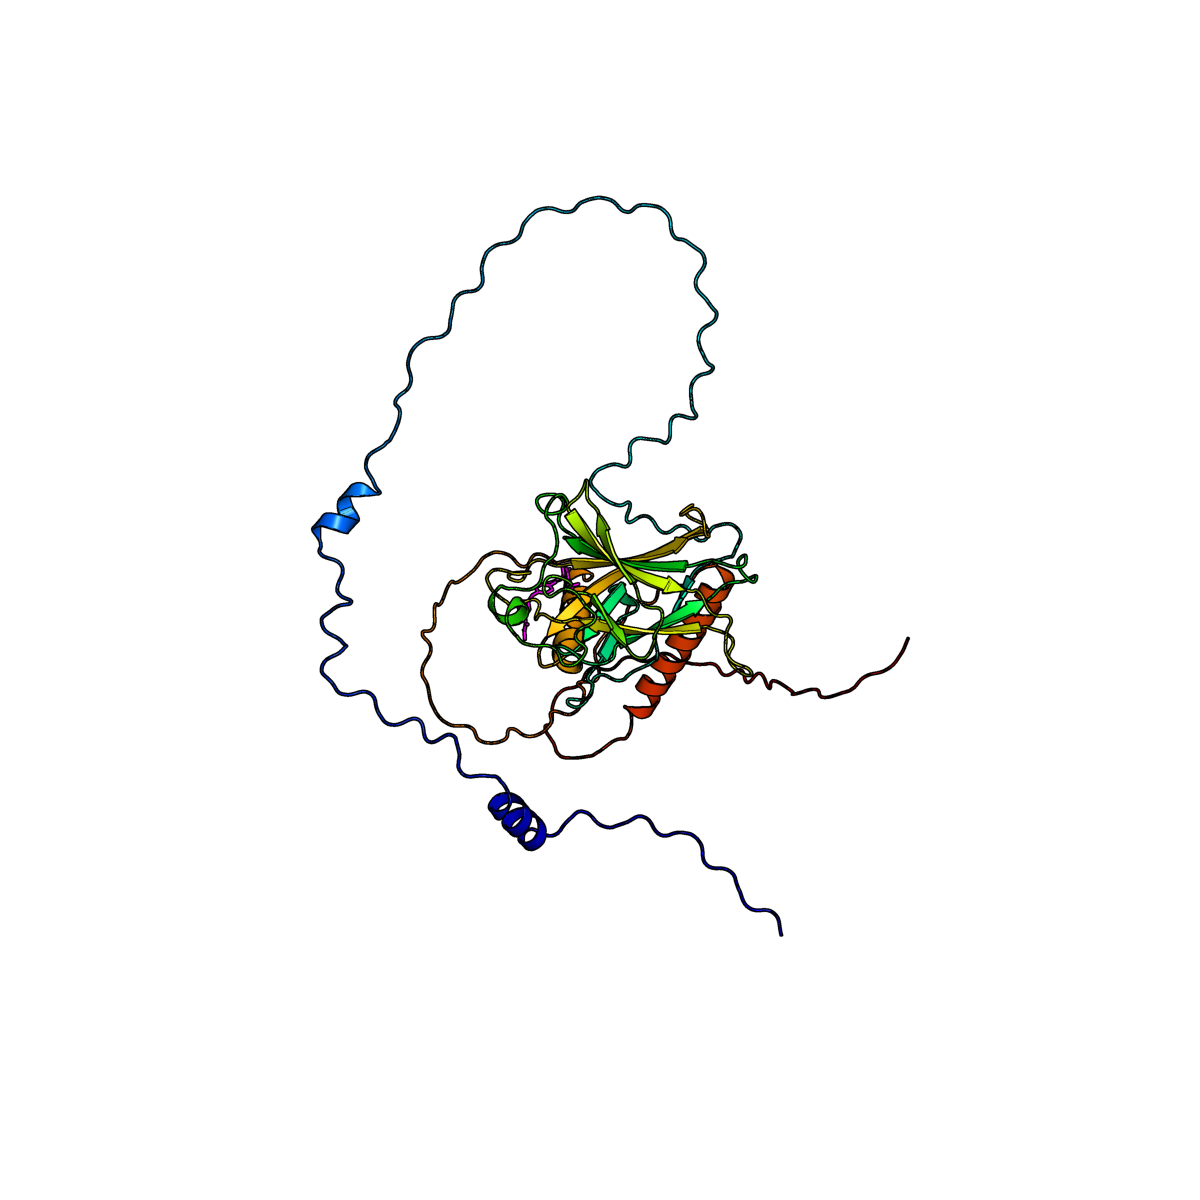


👉 Full complex: rainbow protein + magenta ligand (centered, zoom 25).

🔄 Rendering all complexes...


Processing: 100%|██████████| 150/150 [32:22<00:00, 12.95s/it]



📊 Metadata saved: /content/vis_images/visualization_metadata.csv

📦 Results zipped: /content/docked_complex_images.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ALL DONE!
   Total complexes rendered: 150
   Successful images: 150
   ZIP file downloaded: /content/docked_complex_images.zip


In [17]:
# =============================================================================
# DOCKED COMPLEX VISUALIZATION – FULLY REVISED
#   - Renders full protein + ligand if PDBs are provided
#   - Renders ligand only if only PDBQTs are provided
#   - Rainbow protein, magenta ligand (sticks)
#   - Centered on ligand, zoom all 25 Å padding
# =============================================================================

# -----------------------------------------------------------------------------
# 1. INSTALL DEPENDENCIES
# -----------------------------------------------------------------------------
!apt-get remove -y pymol > /dev/null 2>&1
!apt-get install -y libgl1-mesa-glx libgl1-mesa-dri > /dev/null 2>&1
!pip install -q pymol-open-source biopython pandas openpyxl tqdm

import os
import glob
import zipfile
import subprocess
import pandas as pd
from Bio.PDB import PDBParser, PPBuilder
from google.colab import files
from tqdm import tqdm
from IPython.display import Image, display

print("✅ Dependencies installed.")

# -----------------------------------------------------------------------------
# 2. DIRECTORIES
# -----------------------------------------------------------------------------
UPLOAD_DIR = "/content/structures"
OUTPUT_DIR = "/content/vis_images"
os.makedirs(UPLOAD_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Upload directory: {UPLOAD_DIR}")
print(f"📁 Output directory: {OUTPUT_DIR}")

# =============================================================================
# STEP 1: UPLOAD RECEPTOR PDB FILES (OPTIONAL)
# =============================================================================
print("\n" + "="*70)
print("📤 FIRST UPLOAD (OPTIONAL): RECEPTOR PDB FILES")
print("   These are the protein structures you used for docking.")
print("   - If you have them, upload them now (one or many, or a ZIP).")
print("   - If you only have docked PDBQTs and NO PDBs, click Cancel to skip.")
print("="*70)

uploaded_pdb = files.upload()
for filename, content in uploaded_pdb.items():
    filepath = os.path.join(UPLOAD_DIR, filename)
    with open(filepath, 'wb') as f:
        f.write(content)
    print(f"✅ Saved PDB: {filename}")

# Extract ZIP archives
zip_files = [f for f in os.listdir(UPLOAD_DIR) if f.endswith('.zip')]
for zip_name in zip_files:
    zip_path = os.path.join(UPLOAD_DIR, zip_name)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(UPLOAD_DIR)
    print(f"📦 Extracted PDB ZIP: {zip_name}")
    os.remove(zip_path)

# Count PDB files
pdb_files = glob.glob(os.path.join(UPLOAD_DIR, '*.pdb'))
print(f"\n🔍 Found {len(pdb_files)} PDB files.")

# =============================================================================
# STEP 2: UPLOAD DOCKED PDBQT FILES (REQUIRED)
# =============================================================================
print("\n" + "="*70)
print("📤 SECOND UPLOAD (REQUIRED): DOCKED PDBQT FILES")
print("   These are the ligand poses from Vina (e.g., TP53_G206V_docked.pdbqt).")
print("   Upload all your *_docked.pdbqt files, or a ZIP containing them.")
print("="*70)

uploaded_pdbqt = files.upload()
for filename, content in uploaded_pdbqt.items():
    filepath = os.path.join(UPLOAD_DIR, filename)
    with open(filepath, 'wb') as f:
        f.write(content)
    print(f"✅ Saved PDBQT: {filename}")

# Extract ZIP archives
zip_files = [f for f in os.listdir(UPLOAD_DIR) if f.endswith('.zip')]
for zip_name in zip_files:
    zip_path = os.path.join(UPLOAD_DIR, zip_name)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(UPLOAD_DIR)
    print(f"📦 Extracted PDBQT ZIP: {zip_name}")
    os.remove(zip_path)

# -----------------------------------------------------------------------------
# 3. FIND AND VALIDATE FILES
# -----------------------------------------------------------------------------
pdb_files = glob.glob(os.path.join(UPLOAD_DIR, '*.pdb'))
pdbqt_files = glob.glob(os.path.join(UPLOAD_DIR, '*.pdbqt'))

print(f"\n🔍 Found {len(pdb_files)} PDB files and {len(pdbqt_files)} PDBQT files.")

if not pdbqt_files:
    raise SystemExit("❌ No PDBQT files found. Please upload docked ligand poses.")

# -----------------------------------------------------------------------------
# 4. MATCH RECEPTOR ⇔ LIGAND
# -----------------------------------------------------------------------------
pdb_dict = {}
for pdb in pdb_files:
    base = os.path.splitext(os.path.basename(pdb))[0]
    pdb_dict[base] = pdb

matched_pairs = []
ligand_only = []

for pdbqt in pdbqt_files:
    base = os.path.splitext(os.path.basename(pdbqt))[0]
    if base.endswith('_docked'):
        base_core = base[:-7]
    else:
        base_core = base

    if base_core in pdb_dict:
        matched_pairs.append((pdb_dict[base_core], pdbqt))
    elif len(pdb_files) == 1:
        # Use the single PDB for all ligands
        matched_pairs.append((pdb_files[0], pdbqt))
    else:
        ligand_only.append(pdbqt)

print(f"✅ Matched {len(matched_pairs)} receptor–ligand pairs.")
if ligand_only:
    print(f"⚠️ {len(ligand_only)} ligands have no matching receptor – will render ligand alone.")

if not matched_pairs and ligand_only:
    process_list = [(None, lig) for lig in ligand_only]
elif matched_pairs and ligand_only:
    process_list = matched_pairs + [(None, lig) for lig in ligand_only]
else:
    process_list = matched_pairs

if not process_list:
    raise SystemExit("❌ No structures to visualize.")

# -----------------------------------------------------------------------------
# 5. HELPER: GET SEQUENCE LENGTH FOR RAINBOW
# -----------------------------------------------------------------------------
def get_sequence_length(pdb_path):
    try:
        parser = PDBParser(QUIET=True)
        struct = parser.get_structure('protein', pdb_path)
        ppb = PPBuilder()
        seq = "".join(str(pp.get_sequence()) for pp in ppb.build_peptides(struct))
        return len(seq)
    except:
        return 393  # fallback

# -----------------------------------------------------------------------------
# 6. RENDER FUNCTION
# -----------------------------------------------------------------------------
def render_complex(receptor_pdb, ligand_pdbqt, output_dir):
    base = os.path.splitext(os.path.basename(ligand_pdbqt))[0]
    img_path = os.path.join(output_dir, f"{base}.png")

    pml_lines = []

    if receptor_pdb and os.path.exists(receptor_pdb):
        seq_len = get_sequence_length(receptor_pdb)
        pml_lines.append(f"load {receptor_pdb}, receptor")
        pml_lines.append("hide everything, receptor")
        pml_lines.append("show cartoon, receptor")
        pml_lines.append("spectrum count, rainbow, receptor")

        pml_lines.append(f"load {ligand_pdbqt}, ligand")
        pml_lines.append("hide everything, ligand")
        pml_lines.append("show sticks, ligand")
        pml_lines.append("color magenta, ligand")
    else:
        # Ligand only
        pml_lines.append(f"load {ligand_pdbqt}, ligand")
        pml_lines.append("hide everything, ligand")
        pml_lines.append("show sticks, ligand")
        pml_lines.append("color red, ligand")

    # Center on ligand, zoom all 25
    pml_lines.append("orient ligand")
    pml_lines.append("zoom all, 25")

    # Rendering settings
    pml_lines.extend([
        "viewport 1200, 1200",
        "bg_color white",
        "set ray_trace_mode, 1",
        "set ray_shadows, 0",
        "set depth_cue, 0",
        "set antialias, 2",
        "set cartoon_fancy_helices, 1",
        "draw",
        "ray 1200, 1200",
        f"png {img_path}",
        "quit"
    ])

    pml_script = "\n".join(pml_lines)
    script_file = "/tmp/render.pml"
    with open(script_file, 'w') as f:
        f.write(pml_script)

    result = subprocess.run(['pymol', '-cq', script_file], capture_output=True, text=True)

    if os.path.exists(img_path) and os.path.getsize(img_path) > 5000:
        return img_path
    else:
        print(f"❌ Failed or empty image for {base}")
        if result.stderr:
            print(f"   PyMOL stderr: {result.stderr[:300]}")
        return None

# -----------------------------------------------------------------------------
# 7. TEST RENDER FIRST PAIR
# -----------------------------------------------------------------------------
print("\n🧪 Testing rendering on the first item...")
first_receptor, first_ligand = process_list[0]
test_img = render_complex(first_receptor, first_ligand, OUTPUT_DIR)

if test_img and os.path.exists(test_img):
    print(f"✅ Test image saved: {test_img}")
    display(Image(test_img))
    if first_receptor:
        print("\n👉 Full complex: rainbow protein + magenta ligand (centered, zoom 25).")
    else:
        print("\n👉 Ligand‑only: red sticks (no protein PDB provided).")
else:
    print("❌ Test failed. Please check your files.")

# -----------------------------------------------------------------------------
# 8. BATCH RENDER
# -----------------------------------------------------------------------------
print("\n🔄 Rendering all complexes...")
metadata = []
for receptor_pdb, ligand_pdbqt in tqdm(process_list, desc="Processing"):
    base = os.path.splitext(os.path.basename(ligand_pdbqt))[0]
    img_path = render_complex(receptor_pdb, ligand_pdbqt, OUTPUT_DIR)
    metadata.append({
        'base_name': base,
        'receptor_file': os.path.basename(receptor_pdb) if receptor_pdb else 'None',
        'ligand_file': os.path.basename(ligand_pdbqt),
        'image_generated': 'Yes' if img_path else 'No',
        'image_path': img_path if img_path else ''
    })

# -----------------------------------------------------------------------------
# 9. SAVE METADATA
# -----------------------------------------------------------------------------
df = pd.DataFrame(metadata)
csv_path = os.path.join(OUTPUT_DIR, 'visualization_metadata.csv')
df.to_csv(csv_path, index=False)
print(f"\n📊 Metadata saved: {csv_path}")

# -----------------------------------------------------------------------------
# 10. ZIP AND DOWNLOAD
# -----------------------------------------------------------------------------
zip_path = "/content/docked_complex_images.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for img in glob.glob(os.path.join(OUTPUT_DIR, '*.png')):
        zipf.write(img, os.path.basename(img))
    zipf.write(csv_path, os.path.basename(csv_path))

print(f"\n📦 Results zipped: {zip_path}")
files.download(zip_path)

# -----------------------------------------------------------------------------
# 11. SUMMARY
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("✅ ALL DONE!")
print(f"   Total complexes rendered: {len(metadata)}")
success = sum(1 for m in metadata if m['image_generated'] == 'Yes')
print(f"   Successful images: {success}")
print(f"   ZIP file downloaded: {zip_path}")
print("="*60)